In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors

df = pd.read_csv('cardiovascular_risk_dataset.csv')


Метод info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Patient_ID                        5500 non-null   int64  
 1   age                               5500 non-null   int64  
 2   bmi                               5500 non-null   float64
 3   systolic_bp                       5500 non-null   int64  
 4   diastolic_bp                      5500 non-null   int64  
 5   cholesterol_mg_dl                 5500 non-null   int64  
 6   resting_heart_rate                5500 non-null   int64  
 7   smoking_status                    5500 non-null   object 
 8   daily_steps                       5500 non-null   int64  
 9   stress_level                      5500 non-null   int64  
 10  physical_activity_hours_per_week  5500 non-null   float64
 11  sleep_hours                       5500 non-null   float6

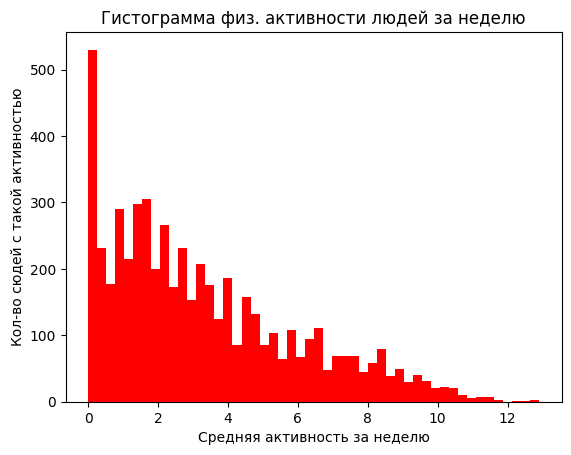

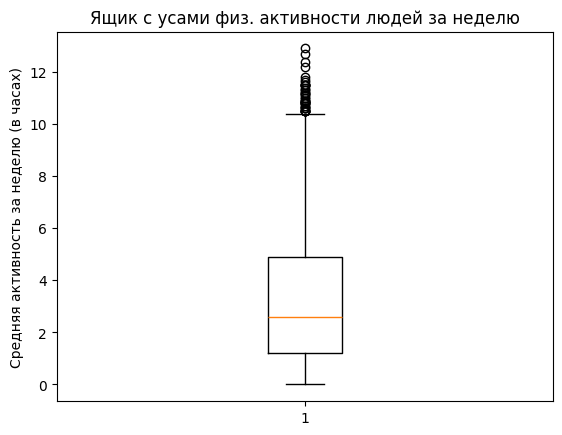

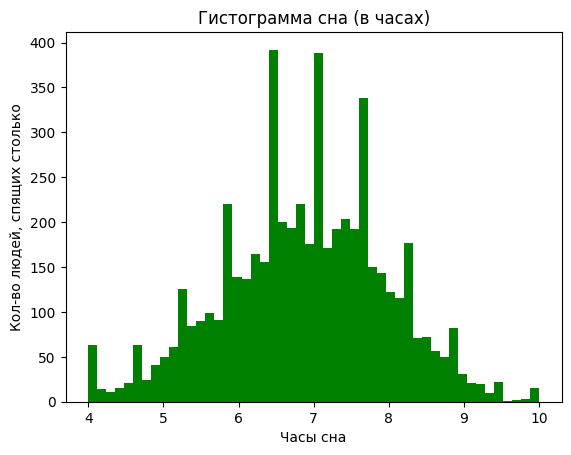

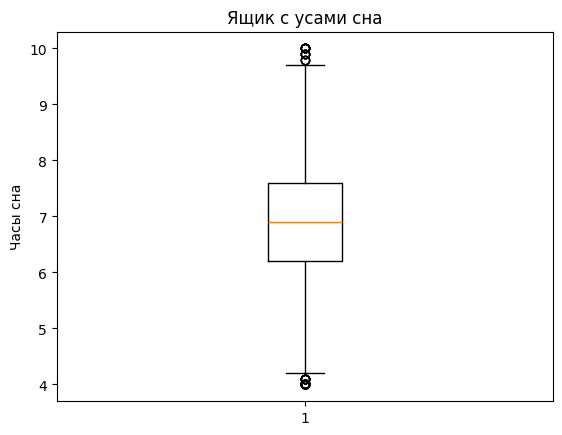

Исходя из данных выше:
1. Люди, что спят меньше 4.5 или больше 9.5 часов - считаются выбросами в базе данных.
2. Возможно всего график сна имеет нормальное распределение.
3. Возможно уравнение регрессии средней активности за неделю имеет график ветви параболы. 
4. Люди, занимающиеся физ. нагрузками больше 10 часов в день  в большинстве своём являются выбросами по меркам boxplot


In [ ]:
# Задание 1. Загрузка и профилирование данных
print('\nМетод info:')
df.info()

print('\nМетод describe:')
df.describe()

print('\nПроверка на нули:')
print(df.isnull().sum())

print('\nМинимальные значения:')
print(df.min())

print('\nМинимальные значения:')
print(df.max())

print()
for item in df:
    if df[item].dtype == np.int16 or df[item].dtype == 'int64':
        print(f"{item} имеет размах: {df[item].max() - df[item].min()}")

print()
plt.hist(df['physical_activity_hours_per_week'], bins=50, color="red")
plt.title("Гистограмма физ. активности людей за неделю")
plt.gca().set_xlabel("Средняя активность за неделю") # gca() = get current axes
plt.gca().set_ylabel("Кол-во сюдей с такой активностью")
plt.show()

plt.boxplot(df['physical_activity_hours_per_week'])
plt.title("Ящик с усами физ. активности людей за неделю")
plt.gca().set_xlabel("")
plt.gca().set_ylabel("Средняя активность за неделю (в часах)")
plt.show()

plt.hist(df['sleep_hours'], bins=50, color="green")
plt.title("Гистограмма сна (в часах)")
plt.gca().set_xlabel("Часы сна")
plt.gca().set_ylabel("Кол-во людей, спящих столько")
plt.show()

plt.boxplot(df['sleep_hours'])
plt.title("Ящик с усами сна")
plt.gca().set_xlabel("")
plt.gca().set_ylabel("Часы сна")
plt.show()

print("Исходя из данных выше:\n1. Люди, что спят меньше 4.5 или больше 9.5 часов - считаются выбросами в базе данных.\n2. Возможно всего график сна имеет нормальное распределение.\n3. Возможно уравнение регрессии средней активности за неделю имеет график ветви параболы. \n4. Люди, занимающиеся физ. нагрузками больше 10 часов в день  в большинстве своём являются выбросами по меркам boxplot")

,Название строки,Физ. активность,Часы сна
0,среднее,3.299364,6.869364
1,медиана,2.600000,6.900000
2,стандартное отклонение,2.672457,1.091263
3,коэффициент асимметрии,0.840968,-0.152763
4,коэффициент эксцесса,-0.072160,-0.119172


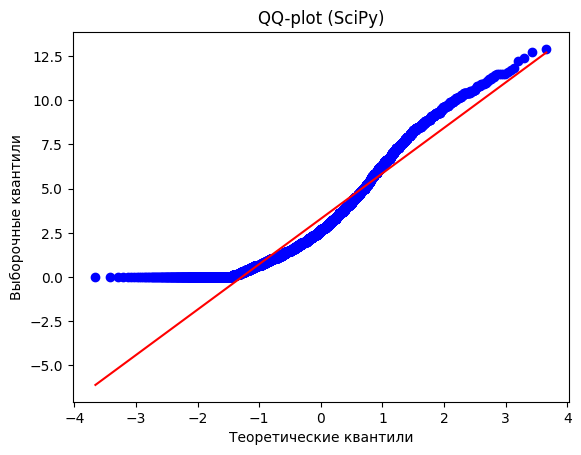

Поскольку QQ график сравнивал данные с нормальным распределением можно сделать вывод, что первые квантили не совпадают (логично предположить, что из-за неотрицательности значений. Нельзя заниматься, например, -3 часа физ. нагрузками в неделю). Но позже значения колеблються вокруг стандартного распределения, уходя сначало ниже, а потом ниже графика


Проверим нормальность распределения физ. нагрузок с помощью критерия Шапиро–Уилка

H0: выборка подчиняется нормальному распределению
H1: выборка не подчиняется нормальному распределению
Уровень значимости: α = 0.05
p-значение: 0.0000
H0 отвергается
Данные не соответствуют нормальному распределению. Значение статистики  0.9223076113299452

А дальше python будет жаловаться, что я использовал метод Шапиро-Уилка на выборку, объемом больше, чем 5000:
Всё то же самое, что и для физ. нагрузок


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5500.
  res = hypotest_fun_out(*samples, **kwds)


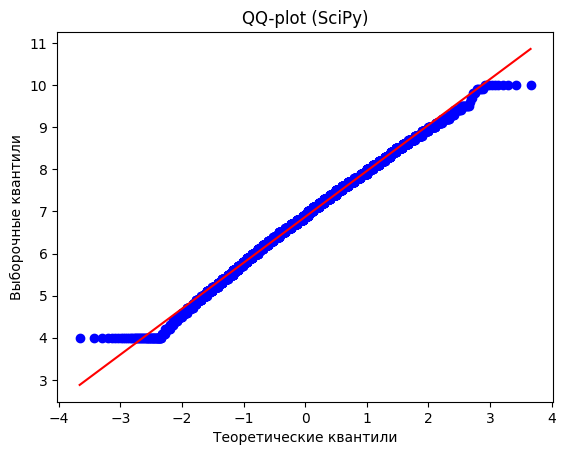

Поскольку QQ график сравнивал данные с нормальным распределением можно сделать вывод, что распределение времени сна почти нормальное (Линия совпадает, за исключением границ)


Проверим нормальность распределения  кол-ва сна с помощью критерия Шапиро–Уилка

H0: выборка подчиняется нормальному распределению
H1: выборка не подчиняется нормальному распределению
Уровень значимости: α = 0.05
p-значение: 0.0000
H0 отвергается (Возможно и по тому, что значений больше 5000)
Данные не соответствуют нормальному распределению. Значение статистики  0.9959890589233453

А дальше python будет жаловаться, что я использовал метод Шапиро-Уилка на выборку, объемом больше, чем 5000:


In [ ]:
# Задание 2. Проверка нормальности распределения

data = {'Название строки': ['среднее', 'медиана', 'стандартное отклонение', 'коэффициент асимметрии', 'коэффициент эксцесса'],
        'Физ. активность': [df['physical_activity_hours_per_week'].mean(), df['physical_activity_hours_per_week'].median(), df['physical_activity_hours_per_week'].std(), df['physical_activity_hours_per_week'].skew(), df['physical_activity_hours_per_week'].kurt()],
        'Часы сна': [df['sleep_hours'].mean(), df['sleep_hours'].median(), df['sleep_hours'].std(), df['sleep_hours'].skew(), df['sleep_hours'].kurt()]}
table = pd.DataFrame(data)
display(table)
print()

stats.probplot(df['physical_activity_hours_per_week'], dist="norm", plot=plt)
plt.title("QQ-plot (SciPy)")
plt.gca().set_xlabel("Теоретические квантили") # gca() = get current axes
plt.gca().set_ylabel("Выборочные квантили")
plt.show()

print("Поскольку QQ график сравнивал данные с нормальным распределением можно сделать вывод, что первые квантили не совпадают (логично предположить, что из-за неотрицательности значений. Нельзя заниматься, например, -3 часа физ. нагрузками в неделю). Но позже значения колеблються вокруг стандартного распределения, уходя сначало ниже, а потом ниже графика\n")

print('\nПроверим нормальность распределения физ. нагрузок с помощью критерия Шапиро–Уилка')

print('\nH0: выборка подчиняется нормальному распределению')
print('H1: выборка не подчиняется нормальному распределению')
print('Уровень значимости: α = 0.05')

alpha = 0.05
stat, pvalue = stats.shapiro(df['physical_activity_hours_per_week'])

print(f"p-значение: {pvalue:.4f}")

if pvalue > alpha:
    print('Нет оснований отвергать H0')
    print('Данные могут соответствовать нормальному распределению. Значение статистики ', stat)
else:
    print('H0 отвергается')
    print('Данные не соответствуют нормальному распределению. Значение статистики ', stat)

print('\nА дальше python будет жаловаться, что я использовал метод Шапиро-Уилка на выборку, объемом больше, чем 5000:')

print('Всё то же самое, что и для физ. нагрузок')

stats.probplot(df['sleep_hours'], dist="norm", plot=plt)
plt.title("QQ-plot (SciPy)")
plt.gca().set_xlabel("Теоретические квантили") # gca() = get current axes
plt.gca().set_ylabel("Выборочные квантили")
plt.show()

print("Поскольку QQ график сравнивал данные с нормальным распределением можно сделать вывод, что распределение времени сна почти нормальное (Линия совпадает, за исключением границ)\n")


print('\nПроверим нормальность распределения  кол-ва сна с помощью критерия Шапиро–Уилка')

print('\nH0: выборка подчиняется нормальному распределению')
print('H1: выборка не подчиняется нормальному распределению')
print('Уровень значимости: α = 0.05')

alpha = 0.05
stat, pvalue = stats.shapiro(df['sleep_hours'])

print(f"p-значение: {pvalue:.4f}")

if pvalue > alpha:
    print('Нет оснований отвергать H0')
    print('Данные могут соответствовать нормальному распределению. Значение статистики ', stat)
else:
    print('H0 отвергается (Возможно и по тому, что значений больше 5000)')
    print('Данные не соответствуют нормальному распределению. Значение статистики ', stat)

print('\nА дальше python будет жаловаться, что я использовал метод Шапиро-Уилка на выборку, объемом больше, чем 5000:')

In [ ]:
# Задание 3. Обнаружение выбросов статистическими методами

print('Будем считать, что количество сна больше приближено к нормальному закону распределдения')

print('Рассчитаем Z-оценки')

zForPh = stats.zscore(df['physical_activity_hours_per_week'])
zForSl = stats.zscore(df['sleep_hours'])

zEjectSl = sum(abs(zForSl) > 3)
zEjectPh = sum(abs(zForPh) > 3)

print(f'Количество выбросов для обеих столбцов: выбросы "по сну"={zEjectSl}; выбросы "по физ. нагрузкам"={zEjectPh}')

print('Визуализация Z-score')

# А как я это сделаю?

q1Sl = np.quantile(df['sleep_hours'], 0.25)
q3Sl = np.quantile(df['sleep_hours'], 0.75)
iqrSl = q3Sl - q1Sl

q1Ph = np.quantile(df['physical_activity_hours_per_week'], 0.25)
q3Ph = np.quantile(df['physical_activity_hours_per_week'], 0.75)
iqrPh = q3Ph - q1Ph

iqrEjectSl = sum(((q1Sl - 1.5 * iqrSl) > zForSl) | (zForSl > (q3Sl + 1.5 * iqrSl)))
iqrEjectPh = sum(((q1Ph - 1.5 * iqrPh) > zForPh) | (zForPh > (q3Ph + 1.5 * iqrPh)))

print(f'Количество выбросов для обеих столбцов: выбросы "по сну"={iqrEjectSl}; выбросы "по физ. нагрузкам"={iqrEjectPh}')

print('Очевидно, что для сна метод z-score не выявил выбросов (z-score опирается на нормальное распределение и, судя по прошлым результатам нормальное распределение соответствует нормальное распределение), но на IQR появилось аж 5500. А для физ. нагрузок в неделю почти наоборот, кроме как 13 в z-score (очевидно, там не полное соответствие. Потому и выбросы)')

Будем считать, что количество сна больше приближено к нормальному закону распределдения
Рассчитаем Z-оценки
Количество выбросов для обеих столбцов: выбросы "по сну"=0; выбросы "по физ. нагрузкам"=13
Визуализация Z-score
Количество выбросов для обеих столбцов: выбросы "по сну"=5500; выбросы "по физ. нагрузкам"=0
Очевидно, что для сна метод z-score не выявил выбросов (z-score опирается на нормальное распределение и, судя по прошлым результатам нормальное распределение соответствует нормальное распределение), но на IQR появилось аж 5500. А для физ. нагрузок в неделю почти наоборот, кроме как 13 в z-score (очевидно, там не полное соответствие. Потому и выбросы)


Осуществим масштабирование
Поскольку средняя активность не подчиняеться нормальному закону:
Эффективнее будет использовать MinMaxScaller, нежели StandartScaller


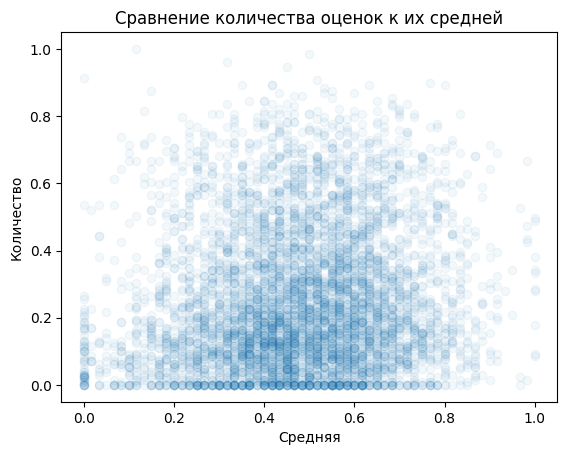

Рассчитаем ближайших соседей при k=5, 7, 10


Для k= 5 :
По среднему расстоянию:
Пороговое значение:  0.0156
Удалено записей:  275 , или же 5.0 %
Осталось записей:  5225

По расстоянию до k-го соседа:
Пороговое значение:  0.0233
Удалено записей:  259 . В процентах это:  4.7091
Осталось записей:  5241



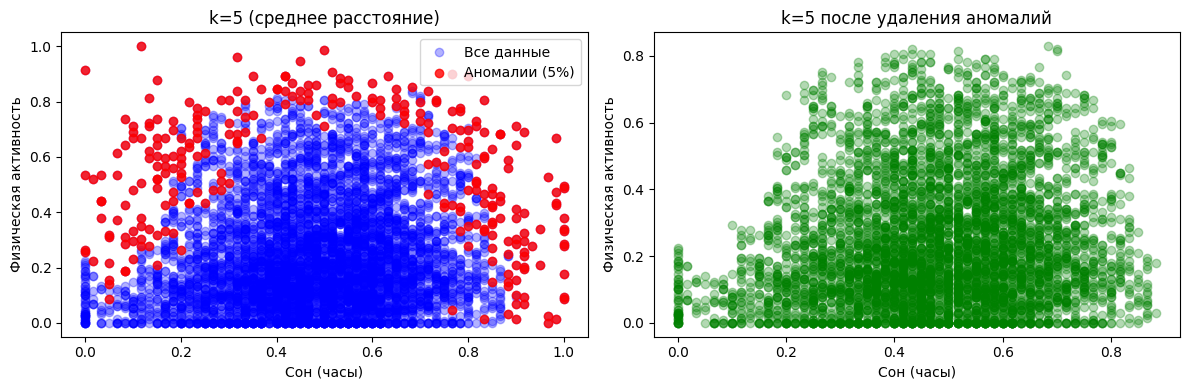



Для k= 7 :
По среднему расстоянию:
Пороговое значение:  0.0156
Удалено записей:  275 , или же 5.0 %
Осталось записей:  5225

По расстоянию до k-го соседа:
Пороговое значение:  0.0333
Удалено записей:  262 . В процентах это:  4.7636
Осталось записей:  5238



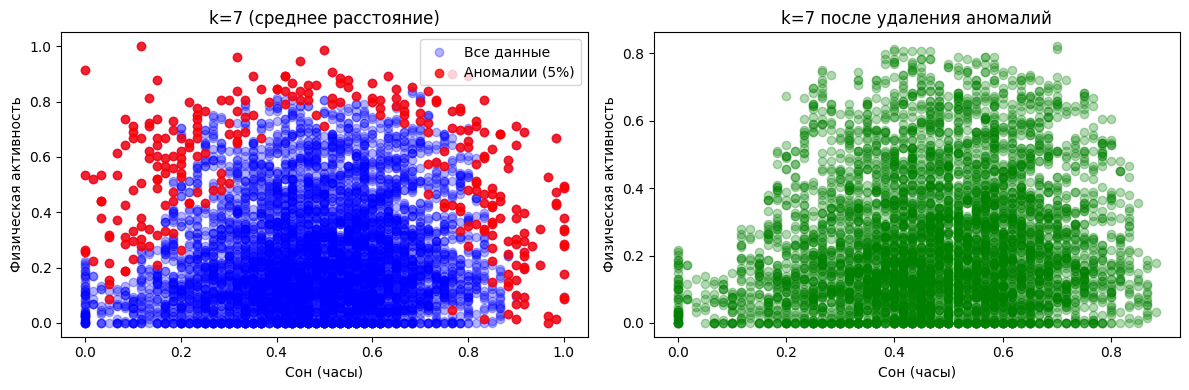



Для k= 10 :
По среднему расстоянию:
Пороговое значение:  0.0156
Удалено записей:  275 , или же 5.0 %
Осталось записей:  5225

По расстоянию до k-го соседа:
Пороговое значение:  0.0368
Удалено записей:  265 . В процентах это:  4.8182
Осталось записей:  5235



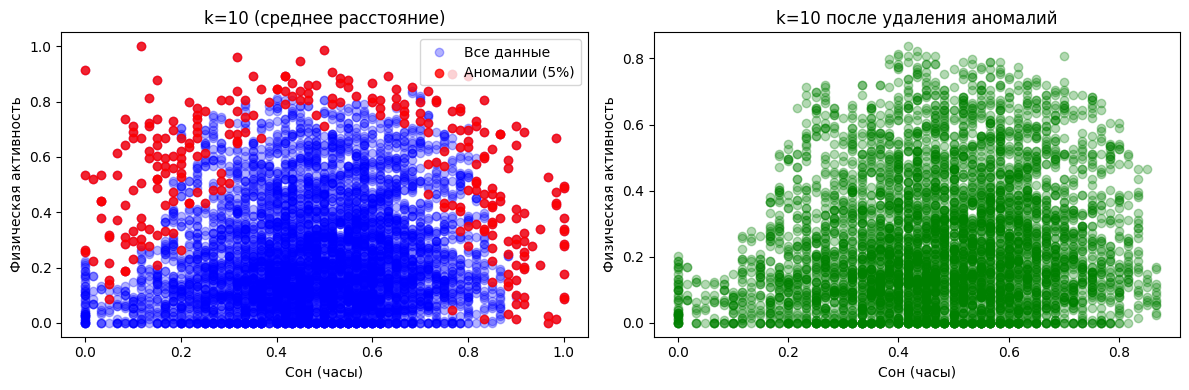

In [ ]:
# Задание 4. Метод локальной плотности

print('Осуществим масштабирование\nПоскольку средняя активность не подчиняеться нормальному закону:\nЭффективнее будет использовать MinMaxScaller, нежели StandartScaller')

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['physical_activity_hours_per_week', 'sleep_hours']].values)

plt.scatter(scaled_data[:, 1], scaled_data[:, 0], alpha=0.05)
plt.title('Сравнение количества оценок к их средней')
plt.xlabel('Средняя')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.show()

print('Рассчитаем ближайших соседей при k=5, 7, 10')

# КАк-то много данных, поэтому проще сделать функиции

def NearestNeighborsFun(k, scaled_data):

  print('\n\nДля k=', k, ":")
  nn = NearestNeighbors(n_neighbors=k, metric='euclidean')
  nn.fit(scaled_data)
  distances5, indices5 = nn.kneighbors(scaled_data)
  c = np.mean(distances5, axis=1)
  distance_to_kth_neighbor5 = distances5[:, -1]

#  proc95 = np.percentile(distances5, 95)
#  filter = distances5 <= proc95
#  filtered_data = scaled_data[filter]

  proc95_mean = np.percentile(mean_distance_to_k_neighbors5, 95)
  filter_mean = mean_distance_to_k_neighbors5 <= proc95_mean
  filtered_data_mean = scaled_data[filter_mean]

  print("По среднему расстоянию:")
  print("Пороговое значение: ", round(proc95_mean, 4))
  print("Удалено записей: ", round(len(scaled_data) - len(filtered_data_mean), 4), ", или же", round((1 - filter_mean.mean())*100, 4), '%')
  print("Осталось записей: ", len(filtered_data_mean))
  print()

  proc95_kth = np.percentile(distance_to_kth_neighbor5, 95)
  filter_kth = distance_to_kth_neighbor5 <= proc95_kth
  filtered_data_kth = scaled_data[filter_kth]

  print("По расстоянию до k-го соседа:")
  print("Пороговое значение: ", round(proc95_kth, 4))
  print("Удалено записей: ", round(len(scaled_data) - len(filtered_data_kth), 4), ". В процентах это: ", round((1 - filter_kth.mean())*100, 4))
  print("Осталось записей: ", len(filtered_data_kth))
  print()

  # Визуализация результатов от DeepSeek`а
  fig, axes = plt.subplots(1, 2, figsize=(12, 4))

  # Исходные данные
  axes[0].scatter(scaled_data[:, 1], scaled_data[:, 0], alpha=0.3, c='blue', label='Все данные')
  axes[0].scatter(scaled_data[~filter_mean, 1], scaled_data[~filter_mean, 0],
                 alpha=0.8, c='red', label='Аномалии (5%)')
  axes[0].set_title(f'k={k} (среднее расстояние)')
  axes[0].set_xlabel('Сон (часы)')
  axes[0].set_ylabel('Физическая активность')
  axes[0].legend()

  # Данные после удаления аномалий
  axes[1].scatter(filtered_data_kth[:, 1], filtered_data_kth[:, 0],
                 alpha=0.3, c='green')
  axes[1].set_title(f'k={k} после удаления аномалий')
  axes[1].set_xlabel('Сон (часы)')
  axes[1].set_ylabel('Физическая активность')

  plt.tight_layout()
  plt.show()

NearestNeighborsFun(5, scaled_data)
NearestNeighborsFun(7, scaled_data)
NearestNeighborsFun(10, scaled_data)

print('\nСудя по графикам, при увеличении числа k всё больше удаляються маленькие скопление точек (внимание на правый верхний угол графиков с зелеными точками)')